# The spreading of metrological usefulness — quantum Fisher information in quenched spin chains

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A quantum sensor is useful because its state carries *correlations*. Chapter 10 has so far treated those correlations
as something one prepares on purpose: twist a coherent spin state, build a GHZ state, encode a phase. But a many-body
system *generates* correlations by itself, simply by evolving. Prepare a product state, switch on a Hamiltonian, and
entanglement grows; some of that entanglement is **metrologically useful**, and it grows and spreads according to
laws of its own.

This notebook follows metrological usefulness — the quantum Fisher information $F_Q$ — through space and time after
a quench. Two complementary experiments.

1. **A global quench.** A whole chain is prepared in a product state and evolved. How fast does $F_Q$ per particle
   grow, what does it saturate at, and how much multipartite entanglement does it certify along the way? Here $F_Q$ is
   a *global* quantity and, as we will derive, it is nothing but the sum of all connected correlations of the
   generator's local parts. Its growth therefore **is** the spreading of correlations, integrated over the chain.
2. **A local encoding.** The phase $\theta$ is imprinted on one or two sites only, and the chain then transports the
   information. The question becomes spatial: if we can only read a block of $l$ contiguous spins, when does the
   signal arrive, and how much of it is there? The answer is a light cone, and in the simplest case we can derive
   the *exact* profile in closed form and check the simulator against it.

The tools are the ones of Chapter 5 — Trotter–Suzuki time evolution with `jax.jit` and `lax.scan` — combined with
the reduced-state quantum Fisher information of notebooks 29 and 30. One idea makes the combination cheap: instead of
recomputing $\rho_\theta(t)$ for several values of $\theta$, we evolve the state **and one tangent vector**
side by side and read every subsystem's $F_Q$ off the pair.

**Road map.**

* **Section 3** — the identity $F_Q[\psi,J_a]=\sum_{ij}C^{aa}_{ij}$ derived, the entanglement-depth witness quoted,
  and the tangent-vector formulation of a $\theta$-dependent time evolution.
* **Section 4** — the numerical toolbox and its validation: TEBD against exact diagonalisation, the block QFI against
  three independent routes.
* **Sections 5–6** — global quenches of the transverse-field Ising and XXZ chains: the QFI density versus time,
  uniform against staggered generators, the certified entanglement depth, the late-time value compared with the
  Haar-random reference $Nd/(d+1)$ of notebook 35, and the correlation matrix $C_{ij}$ that produces it.
* **Sections 7–9** — local encoding: the light cone of the block-resolved QFI, its exact one-magnon solution, the
  measured front velocity with its threshold bias, the two-site "where is the resource" map, and how an interaction
  turns a ballistic magnon into a slow bound pair.
* **Section 10** — an animation of the local QFI profile travelling down the chain.

### What you will learn

*Physics*

* that for a pure state and a generator $J_a=\tfrac12\sum_i\sigma^a_i$ the quantum Fisher information is *exactly*
  the sum of the connected correlators $\langle\sigma^a_i\sigma^a_j\rangle-\langle\sigma^a_i\rangle\langle\sigma^a_j\rangle$;
* why a conserved generator gives $F_Q=0$ for all time and why the *staggered* generator is the right one after a
  Néel quench;
* how the QFI density certifies a growing entanglement depth, and where that growth stops;
* the light-cone structure of metrological information, its velocity, and how an interaction can trap the resource
  in a slow bound state instead of letting it fly.

*Numerical methods*

* carrying a tangent vector through a time evolution instead of finite-differencing in $\theta$;
* one-magnon dynamics as an exact $N\times N$ reference for a $2^N$-dimensional simulation, and a Bessel-function
  closed form obtained by the method of images;
* measuring a front velocity honestly: threshold bias, interpolated crossings, and why a single number that agrees
  with theory to three digits should make you suspicious.

*Implementation practice*

* `lax.scan` over Trotter steps with a two-component carry, `jax.jit` with static qubit indices;
* `jax.vmap` over Hamiltonian parameters;
* space-time heat maps and an embedded GIF built without writing a single file to disk.

### Prerequisites
* [12 — TEBD (Trotter–Suzuki)](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): the time
  evolution used throughout, and its error control;
* [15 — quench dynamics in spin chains](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb):
  quenches, Lieb–Robinson light cones, the quasiparticle picture, and the threshold-bias lesson we repeat here for a
  different observable;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices and the Schmidt decomposition;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb) and
  [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  $F_Q=4\mathrm{Var}(G)$, the mixed-state formula, the subsystem QFI;
* helpful: [35 — one-axis twisting plus Haar scrambling](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb)
  for the value a fully scrambled state settles at.

**Conventions.** Qubit $q$ = tensor axis $q$ = chain site $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$.
Hamiltonians are written in the Pauli convention, $H=\sum J_{aa}\sigma^a_i\sigma^a_{i+1}+\sum h_a\sigma^a_i$, while
generators use collective spins $J_a=\tfrac12\sum_i\sigma^a_i$, so that the standard quantum limit is $F_Q=N$ and the
Heisenberg limit $F_Q=N^2$. Time is measured in units of the inverse coupling ($J_{xx}=1$).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine: the state constructors, `apply_gate`, `heisenberg_terms` (which builds any XXZ/TFIM term list),
`tebd_gates` and `apply_gates` for the time evolution, `exact_evolve` and `dense_hamiltonian` for validation on small
systems, and `qfi_pure` / `qfi_mixed` for the quantum Fisher information.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import base64
import tempfile
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#8c8c8c", "#00868b"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time). JAX is asynchronous, so every timed value is forced
    with `block_until_ready`; we report the MINIMUM over repetitions, which measures the code rather than
    the operating system of a shared machine."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. Theory

### 3.1 The quantum Fisher information *is* the sum of the connected correlations

Take a pure state $\vert\psi\rangle$ and the collective generator $G=J_a=\tfrac12\sum_i\sigma^a_i$. Notebook 29
established $F_Q=4\,\mathrm{Var}(G)$. Expand the variance:

$$\begin{aligned}
F_Q\left[\psi,J_a\right]&=4\left[\langle J_a^2\rangle-\langle J_a\rangle^2\right]
=4\cdot\frac14\sum_{i,j}\left[\langle\sigma^a_i\sigma^a_j\rangle-\langle\sigma^a_i\rangle\langle\sigma^a_j\rangle\right]\\
&=\sum_{i,j}C^{aa}_{ij},\qquad
C^{aa}_{ij}\equiv\langle\sigma^a_i\sigma^a_j\rangle-\langle\sigma^a_i\rangle\langle\sigma^a_j\rangle .
\end{aligned}\tag{1}$$

The two factors of $\tfrac12$ in $J_a$ produce a $\tfrac14$ that cancels the $4$ exactly. Separating the diagonal,
where $(\sigma^a_i)^2=\mathbb 1$:

$$F_Q\left[\psi,J_a\right]=\underbrace{\sum_i\left(1-\langle\sigma^a_i\rangle^2\right)}_{\le\,N}
  \;+\;\sum_{i\neq j}C^{aa}_{ij}. \tag{2}$$

The first sum is at most $N$ and is the whole story for a product state (the standard quantum limit of notebook 29,
rederived in one line). **Everything above the standard quantum limit comes from the connected correlations between
different sites.** After a quench those correlations are created at the light-cone front and spread ballistically, so
the growth of $F_Q$ is the spreading of correlations, integrated over the chain. That single sentence is the physics
of Sections 5 and 6.

The same algebra for a **staggered** generator $G=\tfrac12\sum_i(-1)^i\sigma^a_i$ gives

$$F_Q\left[\psi,J_a^{\rm stag}\right]=\sum_{i,j}(-1)^{i+j}C^{aa}_{ij}, \tag{3}$$

which picks out *antiferromagnetic* correlations. After a Néel quench that is exactly the right question to ask, and
Section 5 shows why the uniform generator is useless there.

### 3.2 The QFI density as a witness of entanglement depth

Notebook 29 quoted the criterion we shall read the curves with. Call a state **$k$-producible** if it is a mixture of
products of blocks of at most $k$ qubits. Writing $N=sk+r$ with $s=\lfloor N/k\rfloor$ and $0\le r<k$, every
$k$-producible state obeys (Hyllus *et al.* 2012; Tóth 2012)

$$F_Q\left[\rho,J_{\mathbf n}\right]\le sk^2+r^2\;\le\;kN . \tag{4}$$

So $F_Q/N>k$ certifies that some block of at least $k+1$ qubits is genuinely entangled: the QFI **density**
$f_Q=F_Q/N$ is, read as an integer, a lower bound on the entanglement depth. We use the sharp form $sk^2+r^2$, not
the looser corollary $kN$.

### 3.3 A $\theta$-dependent evolution needs one extra vector, not three

The pipeline of this notebook is: prepare $\vert\psi_0\rangle$, imprint $\theta$ with a generator $G$, evolve with
$H$ for a time $t$, then look at a subsystem:

$$\vert\psi_\theta(t)\rangle=U(t)\,e^{-i\theta G}\vert\psi_0\rangle,\qquad U(t)=e^{-iHt}. \tag{5}$$

Differentiating at $\theta=0$,

$$\partial_\theta\vert\psi_\theta(t)\rangle\Big\vert_{\theta=0}=-i\,U(t)\,G\vert\psi_0\rangle
  =-i\,\underbrace{U(t)GU^\dagger(t)}_{\textstyle G(t)}\;\vert\psi(t)\rangle . \tag{6}$$

Two readings of the same line, and both matter.

* **Numerically:** define the **tangent vector** $\vert\phi(t)\rangle=U(t)G\vert\psi_0\rangle$. It obeys the *same*
  Schrödinger equation as $\vert\psi(t)\rangle$, so one time evolution with a two-component state carries both. No
  finite differences in $\theta$, no three copies of the state, and the quantum Fisher information of any block
  follows from the pair $(\psi,\phi)$ by the formula of notebook 29,

$$\rho_A=\Psi\Psi^\dagger,\qquad \partial_\theta\rho_A=-i\left(T-T^\dagger\right),\quad T=\Phi\Psi^\dagger, \tag{7}$$

  where $\Psi$ and $\Phi$ are $\psi$ and $\phi$ reshaped into $2^{\vert A\vert}\times2^{N-\vert A\vert}$ matrices.
* **Physically:** the effective generator at time $t$ is the *Heisenberg-evolved* operator $G(t)=U(t)GU^\dagger(t)$.
  If $G$ acts on one site, $G(t)$ acts on a growing region — this is **operator spreading**, the same object that
  Lieb–Robinson bounds constrain and that out-of-time-order correlators measure. The light cone of Section 7 is the
  light cone of $G(t)$, seen through the quantum Fisher information.

One special case is worth stating now because it will be our sharpest test. If $\left[G,H\right]=0$ then
$G(t)=G$ for all $t$; if in addition $\vert\psi_0\rangle$ is an eigenstate of $G$, then $F_Q=0$ forever. This is why
the uniform $J_z$ generator is dead in the XXZ chain, where $J_z$ is conserved.

In [4]:
# ==============================================================================
# STEP 1: the quantum Fisher information of a block, from a state and a tangent vector
#         (derived in notebook 29, Sec. 14; notebook 37 generalises it as used here)
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """SLD quantum Fisher information from a density matrix and its derivative.

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n) over lam_m + lam_n > tol,
           rho = sum_m lam_m |m><m|.    (Derived in notebook 30, Sec. 5.)
    COST   one Hermitian eigendecomposition, O(dim^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def block_qfi(psi, phi, keep, compress=True, tol=1e-12):
    """QFI of the reduced state of the sites `keep`, from the state and its tangent vector -- Eq. (7).

    MATH   Psi = psi with the kept axes moved to the front and reshaped to (2^K, 2^{N-K}); Phi likewise for
           |phi> = G(t)|psi>.  rho_A = Psi Psi^dag,  d rho_A / d theta = -i (T - T^dag),  T = Phi Psi^dag.
    IMPL   `keep` may be any set of sites.  When 2^K > 2^{N-K} a thin QR of [Psi | Phi] projects onto the
           active subspace (dimension <= 2^{N-K+1}): the non-zero spectrum and all matrix elements survive.
    COST   O(8^min(K, N-K)) time, O(2^N) memory.
    JAX    `keep` is a tuple of static Python ints; psi and phi are traced arrays.
    """
    keep = tuple(int(q) for q in keep)
    rest = tuple(q for q in range(psi.ndim) if q not in keep)
    dA = 2 ** len(keep)
    Psi = jnp.transpose(psi, keep + rest).reshape(dA, -1)
    Phi = jnp.transpose(phi, keep + rest).reshape(dA, -1)
    if compress and Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    T_ = Phi @ Psi.conj().T
    return qfi_from_derivative(Psi @ Psi.conj().T, -1j * (T_ - T_.conj().T), tol)


def corr_matrix(psi, P):
    """Connected correlation matrix C_ij = <P_i P_j> - <P_i><P_j> for a single-qubit Pauli P.

    MATH   with |chi_i> = P_i|psi>,   <P_i P_j> = Re <chi_i|chi_j>  (the real part, because P_i P_j and
           P_j P_i are adjoints of each other and the two sites commute for i != j).
    COST   N applications of P (O(N 2^N)) plus N^2 inner products (O(N^2 2^N)).
    """
    N = psi.ndim
    chis = [apply_gate(psi, P, [q]) for q in range(N)]
    m = jnp.stack([jnp.real(jnp.vdot(psi, c)) for c in chis])
    C = jnp.stack([jnp.stack([jnp.real(jnp.vdot(chis[i], chis[j])) for j in range(N)]) for i in range(N)])
    return C - jnp.outer(m, m)


def qfi_staggered(psi, P):
    """F_Q for the staggered generator G = (1/2) sum_i (-1)^i P_i -- Eq. (3), matrix-free."""
    N = psi.ndim
    out = jnp.zeros_like(psi)
    for q in range(N):
        out = out + (-1.0) ** q * apply_gate(psi, P, [q])
    return jnp.real(jnp.vdot(out, out)) - jnp.real(jnp.vdot(psi, out)) ** 2


def entanglement_depth(F_value, N):
    """Largest k+1 such that F_Q > s k^2 + r^2 with s = N//k, r = N%k -- the depth certified by Eq. (4).
    Returns 1 when nothing is certified."""
    depth = 1
    for k in range(1, N + 1):
        s, r = divmod(N, k)
        if F_value > s * k ** 2 + r ** 2 + 1e-9:
            depth = k + 1
    return depth


# --- CHECKPOINT: Eq. (1) -- the sum of connected correlators IS the QFI ------------------
print("Eq. (1):  sum_ij C^aa_ij  versus  4 Var(J_a)\n")
print(f"{'state':>10s} {'P':>3s} | {'sum_ij C_ij':>14s} {'qfi_pure':>14s} {'err':>10s}")
err_id = 0.0
for name, psi in (("GHZ(6)", ghz_state(6)), ("|+>^6", product_state("+" * 6)),
                  ("Neel(6)", product_state("01" * 3)), ("Haar(6)", haar_state(jax.random.PRNGKey(0), 6))):
    for pn, P in (("Z", Z), ("X", X), ("Y", Y)):
        a = float(jnp.sum(corr_matrix(psi, P)))
        b = float(qfi_pure(psi, P))
        err_id = max(err_id, abs(a - b))
        print(f"{name:>10s} {pn:>3s} | {a:14.8f} {b:14.8f} {abs(a - b):10.1e}")
print(f"\nworst deviation: {err_id:.2e}")
assert err_id < 1e4 * TOL

Eq. (1):  sum_ij C^aa_ij  versus  4 Var(J_a)

     state   P |    sum_ij C_ij       qfi_pure        err


    GHZ(6)   Z |    36.00000000    36.00000000    0.0e+00
    GHZ(6)   X |     6.00000000     6.00000000    0.0e+00
    GHZ(6)   Y |     6.00000000     6.00000000    0.0e+00
     |+>^6   Z |     6.00000000     6.00000000    2.7e-15
     |+>^6   X |     0.00000000     0.00000000    6.2e-15
     |+>^6   Y |     6.00000000     6.00000000    2.7e-15
   Neel(6)   Z |     0.00000000     0.00000000    0.0e+00
   Neel(6)   X |     6.00000000     6.00000000    0.0e+00
   Neel(6)   Y |     6.00000000     6.00000000    0.0e+00
   Haar(6)   Z |     5.74174697     5.74174697    8.9e-16
   Haar(6)   X |     7.25101401     7.25101401    8.9e-16
   Haar(6)   Y |     6.87978880     6.87978880    8.9e-16

worst deviation: 6.22e-15


Equation (1) holds to machine precision for every state and every Pauli direction. It is worth pausing on what it
means: **the quantum Fisher information of a collective generator is an ordinary two-point correlation function**,
summed over all pairs. No optimisation, no symmetric logarithmic derivative, nothing exotic — for a pure state and a
collective generator, $F_Q$ is exactly as accessible as a structure factor.

## 4. The toolbox and its validation

The Hamiltonians are the standard one-dimensional family, built by the engine's `heisenberg_terms` as a list of local
terms:

$$H_{\rm XXZ}=\sum_{i}\left(\sigma^x_i\sigma^x_{i+1}+\sigma^y_i\sigma^y_{i+1}+\Delta\,\sigma^z_i\sigma^z_{i+1}\right),
  \qquad
  H_{\rm TFIM}=\sum_i\sigma^z_i\sigma^z_{i+1}+h\sum_i\sigma^x_i . \tag{8}$$

At $\Delta=0$ the XXZ chain is the **XX chain**, which the Jordan–Wigner transformation maps to free fermions; it is
our exactly solvable reference. The transverse-field Ising chain is free as well, and critical at $h=1$.

The evolution is second- or fourth-order Trotter–Suzuki (notebook 12): one step is a fixed list of two-site gates,
applied by `apply_gates`. The loop over steps is a `lax.scan`, so it compiles once instead of unrolling; the carry is
the **pair** $(\psi,\phi)$ of Eq. (6), which is what makes the whole notebook cheap.

In [5]:
# ==============================================================================
# STEP 2: Hamiltonians, and the paired (state, tangent vector) time evolution
# ==============================================================================
def xxz_terms(N, delta=0.0, hx=0.0):
    """H = sum_i (X X + Y Y + delta Z Z)_{i,i+1} + hx sum_i X_i, as a list of local terms (open chain)."""
    return heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=delta, hx=hx)


def tfim_terms(N, h=1.0, hz=0.0):
    """H = sum_i Z_i Z_{i+1} + h sum_i X_i + hz sum_i Z_i.  hz != 0 breaks integrability."""
    return heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=h, hz=hz)


def make_pair_stepper(terms, dt, order=2, n_sub=1):
    """Compile ONE observation interval: `n_sub` Trotter steps applied to the pair (psi, phi).

    JAX    `lax.scan` compiles the inner loop once; the carry is a tuple of two rank-N tensors, which JAX
           treats as a pytree -- the state and its tangent vector travel together, exactly as Eq. (6) asks.
    """
    gates = tebd_gates(terms, dt, order)

    @jax.jit
    def advance(pair):
        def one(carry, _):
            p, f = carry
            return (apply_gates(p, gates), apply_gates(f, gates)), None
        (p, f), _ = lax.scan(one, pair, None, length=n_sub)
        return p, f

    return advance


def evolve_pair(psi0, phi0, terms, dt, n_obs, n_sub, order=2, observe=None):
    """Evolve the pair and record `observe(psi, phi)` after every block of `n_sub` Trotter steps.
    Returns (times, list of observations) with the t = 0 entry included."""
    advance = make_pair_stepper(terms, dt, order, n_sub)
    pair, rec = (psi0, phi0), [observe(psi0, phi0)] if observe is not None else []
    for _ in range(n_obs):
        pair = advance(pair)
        if observe is not None:
            rec.append(observe(*pair))
    return dt * n_sub * np.arange(n_obs + 1), rec


# --- CHECKPOINT 1: Trotter against exact diagonalisation, for the state AND the tangent vector ----
N_V = 8
terms_v = xxz_terms(N_V, delta=0.7)
psi0_v = product_state("01" * (N_V // 2))
phi0_v = 0.5 * apply_gate(psi0_v, X, [0])
T_V = 2.0
print(f"N = {N_V}, XXZ with Delta = 0.7, evolution to t = {T_V}\n")
print(f"{'order':>6s} {'dt':>8s} {'steps':>7s} | {'err(psi)':>11s} {'err(phi)':>11s} {'err F_Q(J_x)':>13s}")
psi_ex = exact_evolve(psi0_v, terms_v, T_V)
phi_ex = exact_evolve(phi0_v, terms_v, T_V)
f_ex = float(qfi_pure(psi_ex, X))
for order, dt in ((2, 0.05), (2, 0.02), (2, 0.01), (4, 0.05), (4, 0.02)):
    n = int(round(T_V / dt))
    adv = make_pair_stepper(terms_v, dt, order, n)
    p, f = adv((psi0_v, phi0_v))
    print(f"{order:6d} {dt:8.3f} {n:7d} | {max_abs(p - psi_ex):11.2e} {max_abs(f - phi_ex):11.2e} "
          f"{abs(float(qfi_pure(p, X)) - f_ex):13.2e}")

# --- CHECKPOINT 2: block_qfi against 4 Var(G) and against qfi_mixed on the reduced state ---------
print(f"\nblock_qfi: no loss must give 4 Var(G); a block must match qfi_mixed(rho_A, G_A)\n")
print(f"{'block':>12s} | {'block_qfi':>13s} {'reference':>13s} {'err':>10s}")
psi_b = exact_evolve(psi0_v, terms_v, 1.3)
phi_b = 0.5 * apply_collective(psi_b, X)                    # collective generator: Eq. (3) of notebook 37 applies
err_b = abs(float(block_qfi(psi_b, phi_b, range(N_V))) - float(qfi_pure(psi_b, X)))
print(f"{'all sites':>12s} | {float(block_qfi(psi_b, phi_b, range(N_V))):13.8f} "
      f"{float(qfi_pure(psi_b, X)):13.8f} {err_b:10.1e}")
for blk in ((0, 1, 2), (2, 3, 4, 5), (3, 4, 5, 6, 7)):
    a = float(block_qfi(psi_b, phi_b, blk))
    b = float(qfi_mixed(rdm(psi_b, blk), collective_dense(X, len(blk))))
    err_b = max(err_b, abs(a - b))
    print(f"{str(blk):>12s} | {a:13.8f} {b:13.8f} {abs(a - b):10.1e}")
print(f"\nworst deviation: {err_b:.2e}")
assert err_b < 1e4 * TOL

N = 8, XXZ with Delta = 0.7, evolution to t = 2.0

 order       dt   steps |    err(psi)    err(phi)  err F_Q(J_x)


     2    0.050      40 |    7.78e-03    3.15e-03      2.12e-04


     2    0.020     100 |    1.24e-03    5.04e-04      3.61e-05


     2    0.010     200 |    3.11e-04    1.26e-04      9.10e-06


     4    0.050      40 |    7.48e-07    4.34e-07      5.71e-08


     4    0.020     100 |    1.91e-08    1.11e-08      1.56e-09

block_qfi: no loss must give 4 Var(G); a block must match qfi_mixed(rho_A, G_A)

       block |     block_qfi     reference        err


   all sites |   10.01730852   10.01730852    8.9e-15


   (0, 1, 2) |    0.36223562    0.36223562    1.7e-16


(2, 3, 4, 5) |    1.61902975    1.61902975    6.7e-16


(3, 4, 5, 6, 7) |    1.99108782    1.99108782    4.4e-16

worst deviation: 8.88e-15


The first table is the ordinary Trotter convergence of notebook 12, with one addition: the tangent vector converges
at the same rate as the state, as it must, since it obeys the same equation. Second order improves by a factor of
about four when $dt$ is halved, fourth order by about sixteen. We use order $4$ with $dt$ small enough that the
Trotter error is far below every physical effect we discuss.

The second table validates `block_qfi` on an evolved, genuinely entangled state: the full system reproduces
$4\,\mathrm{Var}(J_x)$, and every contiguous block reproduces the completely independent route
"build the reduced density matrix, build the restricted generator, call the engine's mixed-state formula". That
second route only works because the generator is a sum of single-site terms — the commutator lemma of notebook 37.
The tangent-vector route of Eq. (7) does not need that assumption, which is why Sections 7–9 can use a *local*
generator whose Heisenberg evolution is an arbitrary many-body operator.

## 5. A global quench: the growth rate of useful entanglement

The first experiment is the standard one. Prepare a product state, switch on a Hamiltonian, and watch

$$f_Q(t)=\frac{F_Q\left[\psi(t),\,J_{\mathbf n}\right]}{N}$$

— the QFI **density** — grow. By Eq. (2), $f_Q=1$ is the standard quantum limit; by Eq. (4), $f_Q>k$ certifies an
entanglement depth of at least $k+1$.

Two quench families, chosen so that the generator question is unavoidable.

* **Transverse-field Ising**, $H=\sum\sigma^z_i\sigma^z_{i+1}+h\sum\sigma^x_i$, quenched from
  $\vert0\rangle^{\otimes N}$ (all spins up, the $h=0$ ground state). We scan $h=0.5$ (ordered side),
  $h=1$ (critical) and $h=2$ (disordered side), with the uniform generator $J_z$.
* **XXZ**, quenched from the Néel state $\vert0101\ldots\rangle$. Here $J_z$ commutes with $H$ and the Néel state is
  a $J_z$ eigenstate, so Section 3.3 predicts $F_Q\left[J_z\right]=0$ at all times. The *staggered* $J_z$ generator of
  Eq. (3) is the one that sees the physics.

For reference, notebook 35 established that a Haar-random state — the fully scrambled end point — has
$\mathbb E\left[F_Q\right]=Nd/(d+1)$ with $d=2^N$, i.e. $f_Q\to1$: **a fully scrambled state carries no useful
entanglement at all**. Whatever the quench builds must therefore either stay below that or be a transient.

In [6]:
# ==============================================================================
# STEP 3: QFI density after global quenches
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_G = 12                        # 2^12 amplitudes
DT_G, NSUB_G, NOBS_G = 0.05, 1, 120      # Trotter step, steps per observation, observations -> t_max = 6
ORDER_G = 4
# -----------------------------------------------------------------------------

QUENCHES = [
    ("TFIM $h=0.5$", tfim_terms(N_G, 0.5), product_state("0" * N_G), "uniform"),
    ("TFIM $h=1$",   tfim_terms(N_G, 1.0), product_state("0" * N_G), "uniform"),
    ("TFIM $h=2$",   tfim_terms(N_G, 2.0), product_state("0" * N_G), "uniform"),
    ("XXZ $\\Delta=0.5$, Neel", xxz_terms(N_G, 0.5), product_state("01" * (N_G // 2)), "both"),
    ("XXZ $\\Delta=2$, Neel",   xxz_terms(N_G, 2.0), product_state("01" * (N_G // 2)), "both"),
]


def quench_observables(psi, _phi):
    """(F_Q[J_x], F_Q[J_y], F_Q[J_z], F_Q[staggered J_z], S_half) of a pure state."""
    return jnp.stack([qfi_pure(psi, X), qfi_pure(psi, Y), qfi_pure(psi, Z),
                      qfi_staggered(psi, Z), entanglement_entropy(psi, range(psi.ndim // 2))])


results_g = {}
t0 = time.time()
for label, terms, psi0, _kind in QUENCHES:
    ts, rec = evolve_pair(psi0, psi0, terms, DT_G, NOBS_G, NSUB_G, ORDER_G, observe=quench_observables)
    results_g[label] = (ts, np.array(rec))
print(f"five quenches at N = {N_G} up to t = {ts[-1]:.1f}  ({time.time() - t0:.1f} s)\n")

HAAR_REF = 2 ** N_G / (2 ** N_G + 1)
print(f"QFI density f_Q = F_Q/N   (SQL: 1;  Heisenberg: N = {N_G};  Haar: {HAAR_REF:.4f})\n")
print(f"{'quench':>24s} {'generator':>12s} | " + " ".join(f"t={t:<6.1f}" for t in (0.25, 0.5, 1, 2, 4, 6))
      + f" {'max f_Q':>8s} {'depth':>6s}")
for label, (ts, rec) in results_g.items():
    for gname, col in (("J_z", 2), ("J_z stag.", 3)):
        if "TFIM" in label and gname != "J_z":
            continue
        if "XXZ" in label and gname == "J_z" and float(np.max(rec[:, 2])) < 1e-9:
            print(f"{label:>24s} {gname:>12s} | " + " ".join(f"{0.0:7.3f}" for _ in range(6))
                  + f" {0.0:8.3f} {1:6d}     (conserved: exactly zero)")
            continue
        vals = rec[:, col] / N_G
        idx = [int(round(t / (DT_G * NSUB_G))) for t in (0.25, 0.5, 1, 2, 4, 6)]
        dep = entanglement_depth(float(np.max(rec[:, col])), N_G)
        print(f"{label:>24s} {gname:>12s} | " + " ".join(f"{vals[i]:7.3f}" for i in idx)
              + f" {vals.max():8.3f} {dep:6d}")

five quenches at N = 12 up to t = 6.0  (42.9 s)

QFI density f_Q = F_Q/N   (SQL: 1;  Heisenberg: N = 12;  Haar: 0.9998)

                  quench    generator | t=0.2    t=0.5    t=1.0    t=2.0    t=4.0    t=6.0     max f_Q  depth
            TFIM $h=0.5$          J_z |   0.057   0.183   0.434   0.799   1.784   2.582    2.582      3
              TFIM $h=1$          J_z |   0.218   0.676   1.836   2.321   2.315   4.823    4.823      6
              TFIM $h=2$          J_z |   0.706   1.441   1.785   2.504   2.645   2.097    3.392      4
  XXZ $\Delta=0.5$, Neel          J_z |   0.000   0.000   0.000   0.000   0.000   0.000    0.000      1     (conserved: exactly zero)
  XXZ $\Delta=0.5$, Neel    J_z stag. |   1.399   1.081   1.553   1.511   1.999   2.439    2.757      3
    XXZ $\Delta=2$, Neel          J_z |   0.000   0.000   0.000   0.000   0.000   0.000    0.000      1     (conserved: exactly zero)
    XXZ $\Delta=2$, Neel    J_z stag. |   1.577   2.899   2.977   3.968   4.361   3.8

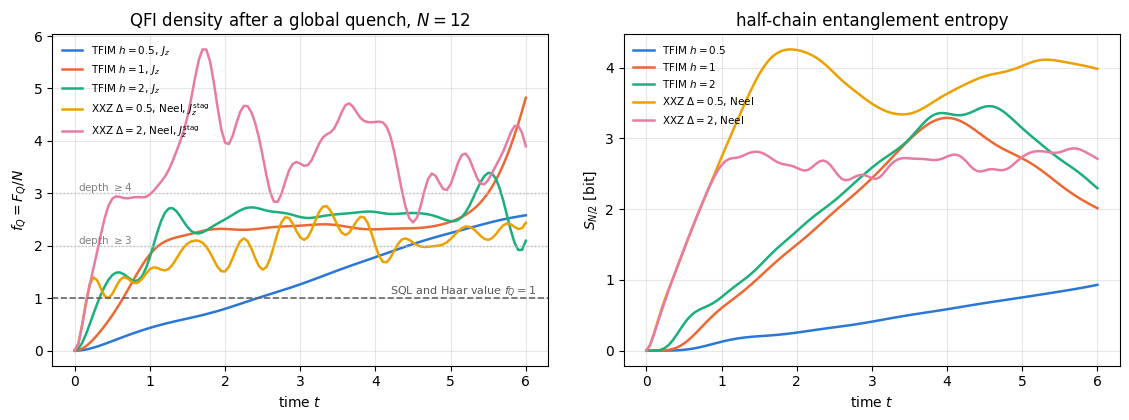

In [7]:
# ==============================================================================
# FIGURE 1: QFI density and entanglement entropy after the quenches
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
j = 0
for label, (ts, rec) in results_g.items():
    col = 2 if "TFIM" in label else 3
    gl = r"$J_z$" if "TFIM" in label else r"$J_z^{\mathrm{stag}}$"
    axes[0].plot(ts, rec[:, col] / N_G, "-", color=PALETTE[j], lw=1.8, label=f"{label}, {gl}")
    axes[1].plot(ts, rec[:, 4], "-", color=PALETTE[j], lw=1.8, label=label)
    j += 1
axes[0].axhline(1.0, color="0.4", ls="--", lw=1.2)
axes[0].text(4.2, 1.06, "SQL and Haar value $f_Q=1$", fontsize=8, color="0.35")
for k in (2, 3):
    axes[0].axhline(k, color="0.75", ls=":", lw=1.0)
    axes[0].text(0.05, k + 0.04, f"depth $\\geq{k + 1}$", fontsize=7.5, color="0.5")
axes[0].set_xlabel("time $t$"); axes[0].set_ylabel(r"$f_Q=F_Q/N$")
axes[0].set_title(f"QFI density after a global quench, $N={N_G}$"); axes[0].legend(fontsize=7.5, loc="upper left")
axes[1].set_xlabel("time $t$"); axes[1].set_ylabel(r"$S_{N/2}$ [bit]")
axes[1].set_title("half-chain entanglement entropy"); axes[1].legend(fontsize=7.5, loc="upper left")
fig.tight_layout(); plt.show()

Five curves, five different stories, and every one of them is readable from Section 3.

**The dead generator.** The two XXZ rows with $G=J_z$ print zeros — not small numbers, exact zeros. $J_z$ commutes
with $H_{\rm XXZ}$ (the model conserves the total magnetisation) and the Néel state is a $J_z$ eigenstate, so by
Section 3.3 the state never moves under the encoding and no measurement can learn $\theta$. This is the single most
common way to waste a metrology experiment, and it costs nothing to check in advance: compute $\left[G,H\right]$.

**Speed depends on the quench.** With the *staggered* generator the same XXZ quenches are very much alive. The
deeper quench $\Delta=2$ is the faster one, passing the standard quantum limit almost immediately
($f_Q=1.58$ already at $t=0.2$) and reaching $f_Q\approx4$ by $t=2$; at $\Delta=0.5$ the growth is slower and
smoother. In the Ising family the ordering is the opposite of the naive one: the critical quench $h=1$ grows fastest
at intermediate times ($f_Q=1.84$ at $t=1$ against $1.79$ for $h=2$ and $0.43$ for $h=0.5$), while $h=2$ is fastest at
very short times — the transverse field is what makes the initial state move at all, so a bigger field starts the
clock earlier.

**The certified entanglement depth.** Reading Eq. (4) off the maxima: depth $\ge6$ for the critical Ising quench and
for XXZ at $\Delta=2$, $\ge4$ for $h=2$, $\ge3$ for $h=0.5$ and for XXZ at $\Delta=0.5$. A quench with no
entanglement engineering at all produces genuinely six-partite entangled blocks in a chain of twelve spins.

**Nothing settles at the Haar value.** A fully scrambled state would sit at $f_Q=0.9998$ (notebook 35); every curve
here lives well above $1$, and the Ising curve at $h=1$ ends *higher* than it was at $t=2$, rising to $f_Q=4.82$ at
$t=6$. That late rise is a finite-size revival: the half-chain entropy in the right panel peaks near $t\approx4$ and
then *falls*, which is what a chain of $N=12$ does when the quasiparticles that left the middle come back from the
ends. The physically meaningful window at this size is roughly $t\lesssim4$, and inside it the densities plateau at
$2$–$4$, comfortably above the scrambled value.

> **Physics insight.** "Entanglement entropy grows towards its maximum" and "useful entanglement decays to the
> standard quantum limit" are different statements, and both are true of different quantities. The half-chain entropy
> climbs towards its Page value; the quantum Fisher information density measures only the *collective, low-order*
> correlations of Eq. (2), and those do not have to disappear when a state becomes complicated. Which is why $f_Q$ is
> a useful diagnostic and not just another entropy.

### 5.1 Scanning the anisotropy with `vmap`

The table above used two values of $\Delta$. A parameter sweep is the natural place for `jax.vmap`: the anisotropy
enters the Hamiltonian as an ordinary number, `tebd_gates` diagonalises the two-site term with `eigh`, and none of
that cares whether $\Delta$ is a Python float or a traced array. Writing the whole "build the gates, run the scan,
measure $f_Q$" pipeline as a pure function of $\Delta$ and mapping it over a grid gives the entire phase diagram in
one compiled program.

In [8]:
# ==============================================================================
# STEP 3b: f_Q(t) as a function of the XXZ anisotropy -- one vmapped program
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "n_obs", "n_sub", "order"))
def fq_stag_vs_time(delta, N, dt, n_obs, n_sub, order=2):
    """f_Q(t) = F_Q[psi(t), J_z^stag]/N after a Neel quench of the XXZ chain with anisotropy `delta`.

    JAX  `delta` is TRACED: it flows into the two-site term, through the `eigh` inside `tebd_gates` and into
         every gate, so the function is vmap-able over a grid of anisotropies.  N, n_obs, n_sub and the
         Trotter order are static because they fix the shapes and the einsum strings.
    """
    gates = tebd_gates(heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=delta), dt, order)

    def block(p, _):
        p, _ = lax.scan(lambda q, _: (apply_gates(q, gates), None), p, None, length=n_sub)
        return p, qfi_staggered(p, Z) / N

    _, rec = lax.scan(block, product_state("01" * (N // 2)), None, length=n_obs)
    return rec


N_D, DT_D, NOBS_D, NSUB_D = 10, 0.02, 25, 4          # t_max = 25 * 4 * 0.02 = 2.0
DELTAS = jnp.linspace(0.0, 3.0, 13)
t0 = time.time()
sweep = np.array(jax.vmap(partial(fq_stag_vs_time, N=N_D, dt=DT_D, n_obs=NOBS_D, n_sub=NSUB_D))(DELTAS))
ts_d = DT_D * NSUB_D * np.arange(1, NOBS_D + 1)
print(f"{len(DELTAS)} anisotropies x {NOBS_D} times at N = {N_D}, vmapped ({time.time() - t0:.1f} s)\n")
print(f"{'Delta':>6s} | " + " ".join(f"t={t:<5.1f}" for t in (0.25, 0.5, 1.0, 1.5, 2.0)))
for i, d in enumerate(np.array(DELTAS)):
    idx = [int(round(t / (DT_D * NSUB_D))) - 1 for t in (0.25, 0.5, 1.0, 1.5, 2.0)]
    print(f"{d:6.2f} | " + " ".join(f"{sweep[i, j]:6.3f}" for j in idx))

13 anisotropies x 25 times at N = 10, vmapped (1.5 s)

 Delta | t=0.2   t=0.5   t=1.0   t=1.5   t=2.0  
  0.00 |  1.367  0.755  1.003  1.594  0.876
  0.25 |  1.371  0.827  1.141  1.776  1.428
  0.50 |  1.382  1.030  1.478  2.047  2.201
  0.75 |  1.400  1.335  1.831  2.074  2.742
  1.00 |  1.422  1.695  2.076  2.050  3.309
  1.25 |  1.445  2.060  2.274  2.410  3.433
  1.50 |  1.467  2.383  2.552  3.297  2.569
  1.75 |  1.485  2.627  2.899  4.555  2.776
  2.00 |  1.496  2.771  3.173  5.364  4.344
  2.25 |  1.497  2.813  3.303  4.959  4.157
  2.50 |  1.487  2.764  3.373  4.117  3.291
  2.75 |  1.464  2.647  3.487  3.668  3.659
  3.00 |  1.428  2.490  3.614  3.384  4.259


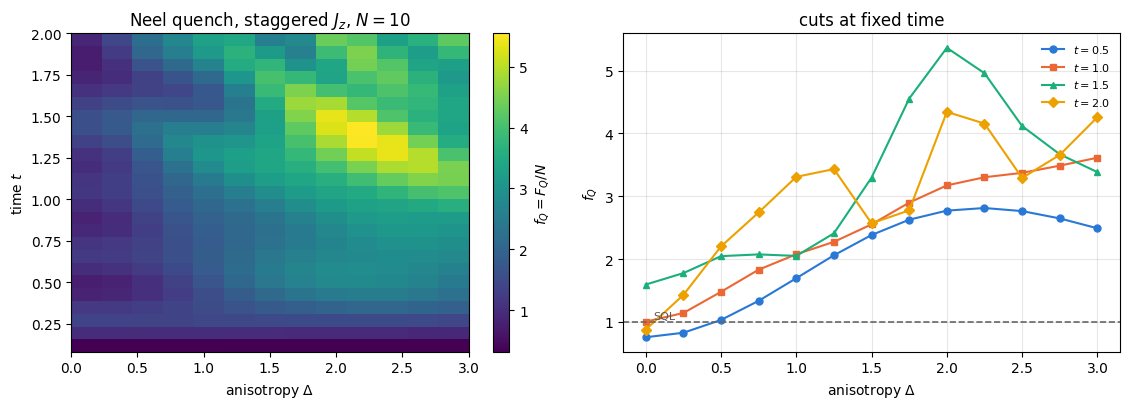

In [9]:
# ==============================================================================
# FIGURE 2: QFI density versus anisotropy and time
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
im = axes[0].imshow(sweep.T, origin="lower", aspect="auto", cmap="viridis",
                    extent=[float(DELTAS[0]), float(DELTAS[-1]), ts_d[0], ts_d[-1]])
fig.colorbar(im, ax=axes[0], label=r"$f_Q=F_Q/N$")
axes[0].set_xlabel(r"anisotropy $\Delta$"); axes[0].set_ylabel("time $t$"); axes[0].grid(False)
axes[0].set_title(f"Neel quench, staggered $J_z$, $N={N_D}$")
for j, t_show in enumerate((0.5, 1.0, 1.5, 2.0)):
    i = int(round(t_show / (DT_D * NSUB_D))) - 1
    axes[1].plot(np.array(DELTAS), sweep[:, i], MARKERS[j] + "-", color=PALETTE[j], ms=5,
                 label=f"$t={t_show}$")
axes[1].axhline(1.0, color="0.4", ls="--", lw=1.2)
axes[1].text(0.05, 1.05, "SQL", fontsize=8, color="0.35")
axes[1].set_xlabel(r"anisotropy $\Delta$"); axes[1].set_ylabel(r"$f_Q$")
axes[1].set_title("cuts at fixed time"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Thirteen anisotropies, twenty-five times, one compiled program, under a second of run time. `vmap` did not make the
arithmetic cheaper — it made it *batched*, so XLA runs thirteen copies of the same Trotter circuit on stacked arrays
instead of thirteen Python loops with thirteen dispatches each.

The physics is a clear optimum at intermediate coupling. At very short times ($t=0.24$) the density is almost
independent of $\Delta$, between $1.37$ and $1.50$: the first thing the quench does is destroy the perfect Néel
order, and that happens at a rate set by the $XY$ terms, which are the same for every $\Delta$. By $t=1.5$ the
curve has developed a pronounced maximum at $\Delta\approx2$, where $f_Q=5.36$ — more than five times the standard
quantum limit and an entanglement depth of at least $6$ at $N=10$.

Both limits are bad, for opposite reasons. At $\Delta=0$ (the XX chain) the dynamics is free, the staggered
correlations that Eq. (3) sums never build up, and $f_Q$ oscillates around $1$, dipping to $0.76$ at $t=0.5$ —
*below* the standard quantum limit, i.e. the state is not even useful. At large $\Delta$ the Néel state is close to
an eigenstate of the dominant $\Delta\sum\sigma^z\sigma^z$ term, so the dynamics is slow and the growth of $f_Q$ is
pushed to later times: at $t=1.5$ the $\Delta=3$ value has fallen back to $3.38$. The best probe is made by a chain
that interacts strongly enough to correlate but not so strongly that it freezes.

## 6. Reading the growth: correlations, and where it stops

Equation (1) says the curves of Figure 1 are nothing but $\sum_{ij}C_{ij}$, so the correlation matrix itself should
show the mechanism. We take one quench and plot $C^{zz}_{ij}$ at several times.

In [10]:
# ==============================================================================
# STEP 4: the correlation matrix behind the QFI density
# ==============================================================================
N_C = 12
TERMS_C = tfim_terms(N_C, 1.0)
psi0_c = product_state("0" * N_C)
T_SNAP = [0.0, 0.5, 1.5, 3.0]

snaps_c, sums_c = [], []
pair = (psi0_c, psi0_c)
t_now = 0.0
for k, t_target in enumerate(T_SNAP):
    if t_target > t_now:
        n = int(round((t_target - t_now) / DT_G))
        pair = make_pair_stepper(TERMS_C, DT_G, ORDER_G, n)(pair)
        t_now = t_target
    C = np.array(corr_matrix(pair[0], Z))
    snaps_c.append(C)
    sums_c.append((float(C.sum()), float(qfi_pure(pair[0], Z)), float(np.sum(np.diag(C))),
                   float(C.sum() - np.sum(np.diag(C)))))

print(f"TFIM h = 1, N = {N_C}, quench from |0>^N:  decomposition of Eq. (2)\n")
print(f"{'t':>6s} | {'sum_ij C_ij':>12s} {'F_Q (direct)':>13s} {'diagonal':>10s} {'off-diagonal':>13s} {'f_Q':>7s}")
for t, (s, f, d, o) in zip(T_SNAP, sums_c):
    print(f"{t:6.2f} | {s:12.5f} {f:13.5f} {d:10.5f} {o:13.5f} {f / N_C:7.3f}")

TFIM h = 1, N = 12, quench from |0>^N:  decomposition of Eq. (2)

     t |  sum_ij C_ij  F_Q (direct)   diagonal  off-diagonal     f_Q
  0.00 |      0.00000       0.00000    0.00000       0.00000   0.000
  0.50 |      8.10866       8.10866    7.01315       1.09550   0.676
  1.50 |     26.53435      26.53435   11.73456      14.79980   2.211
  3.00 |     28.61102      28.61102   11.99289      16.61813   2.384


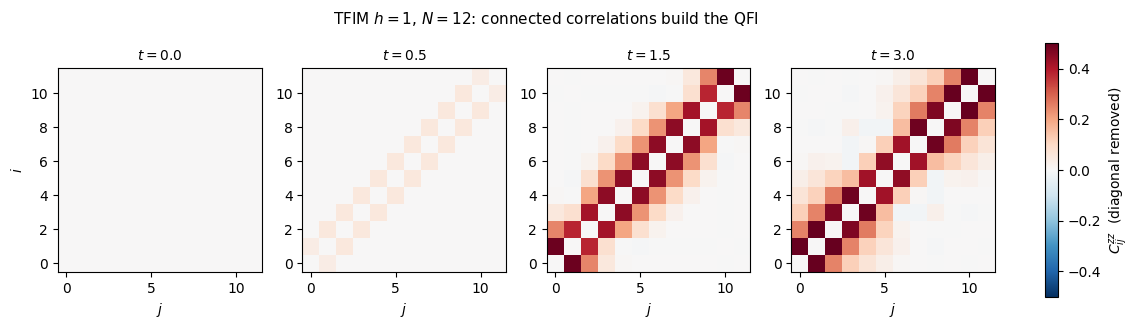

In [11]:
# ==============================================================================
# FIGURE 3: the connected correlation matrix C^zz_ij spreading
# ==============================================================================
vmax = max(np.abs(C - np.diag(np.diag(C))).max() for C in snaps_c)
fig, axes = plt.subplots(1, len(T_SNAP), figsize=(13.0, 3.3))
for ax, t, C in zip(axes, T_SNAP, snaps_c):
    M = C - np.diag(np.diag(C))                      # hide the (large, trivial) diagonal
    im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(f"$t={t:.1f}$", fontsize=10)
    ax.set_xlabel("$j$"); ax.grid(False)
axes[0].set_ylabel("$i$")
fig.colorbar(im, ax=axes, fraction=0.02, label=r"$C^{zz}_{ij}$  (diagonal removed)")
fig.suptitle(f"TFIM $h=1$, $N={N_C}$: connected correlations build the QFI", fontsize=11)
plt.show()

The table decomposes Eq. (2) and the figure shows where the two pieces come from.

The **diagonal** part $\sum_i\left(1-\langle\sigma^z_i\rangle^2\right)$ climbs from $0$ (the initial state is fully
polarised along $z$, so $\langle\sigma^z_i\rangle=1$ and every term vanishes) to $11.99$ at $t=3$, i.e. to $N=12$:
the local magnetisation has relaxed to zero and each site contributes its maximum of one. That part alone is the
standard quantum limit and it saturates early.

The **off-diagonal** part is the interesting one: $0\to1.10\to14.80\to16.62$ at $t=0,0.5,1.5,3$. From $t\approx1$
onwards it is the *larger* of the two, and it is what pushes $f_Q$ above $1$. The colour maps say exactly where it
comes from: at $t=0$ the matrix is empty; at $t=0.5$ a thin band has appeared along the diagonal; at $t=1.5$ the band
has widened to about four sites on either side and the whole matrix is covered by $t=3$. Correlations are created at
the light cone and the QFI is their integral — a diagonal band of half-width $r(t)$ contributes $O(Nr)$ to the sum,
so a linearly expanding cone gives a linearly growing $F_Q$ until the cone fills the chain. The plateau of Figure 1
is that saturation, not the approach to a scrambled state.

> **Numerical practice.** The diagonal of $C_{ij}$ is bounded by $1$ and the off-diagonal entries are an order of
> magnitude smaller, so a heat map that includes the diagonal shows a bright line and nothing else. Removing the
> diagonal before plotting is not cosmetic: it is the difference between a figure that shows the physics and one
> that shows the normalisation.

### 6.1 Intensivity of the density

$f_Q=F_Q/N$ deserves the name "density" only if it stops depending on $N$. The off-diagonal sum of Eq. (2) runs over
$N^2$ pairs, but correlations decay with distance, so each site contributes a bounded amount and the sum should grow
like $N$ — that is the argument, and it needs checking, particularly at a critical point where correlations are
long-ranged.

In [12]:
# ==============================================================================
# STEP 4b: does f_Q depend on the system size?
# ==============================================================================
print(f"TFIM h = 1, quench from |0>^N:  f_Q = F_Q/N for three system sizes\n")
print(f"{'N':>3s} | " + " ".join(f"t={t:<6.1f}" for t in (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)))
for N in (8, 10, 12):
    p0 = product_state("0" * N)
    ts_s, rec_s = evolve_pair(p0, p0, tfim_terms(N, 1.0), DT_G, 60, NSUB_G, ORDER_G,
                              observe=lambda p, _f: qfi_pure(p, Z))
    v = np.array(rec_s) / N
    idx = [int(round(t / (DT_G * NSUB_G))) for t in (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)]
    print(f"{N:3d} | " + " ".join(f"{v[i]:7.3f}" for i in idx))

TFIM h = 1, quench from |0>^N:  f_Q = F_Q/N for three system sizes

  N | t=0.5    t=1.0    t=1.5    t=2.0    t=2.5    t=3.0   


  8 |   0.677   1.778   2.044   2.155   2.129   2.108


 10 |   0.676   1.813   2.142   2.227   2.286   2.269


 12 |   0.676   1.836   2.211   2.321   2.334   2.384


At short times the density is intensive to three digits: $f_Q=0.677,0.676,0.676$ at $t=0.5$ for $N=8,10,12$. That is
the regime in which the light cone is smaller than the chain, so every site sees the same neighbourhood and the sum
of Eq. (2) is strictly proportional to $N$.

Once the cone reaches the ends the sizes separate: at $t=3$ we measure $2.108$, $2.269$ and $2.384$, a drift of about
$6\%$ per two spins that shows no sign of having converged. The reason is the same finite-size effect as in the
previous figure — a longer chain has not yet finished filling its correlation band. **Nothing in this notebook
extrapolates to the limit $N\to\infty$**; the numbers quoted for late times are properties of a chain of $12$ or
$14$ spins, and they should be read as such.

## 6.2 A short summary before the second half

Sections 5 and 6 answered the *global* question: how much useful entanglement a quench builds, how fast, and out of
which correlations. The rest of the notebook asks the *spatial* question instead, and to do that the encoding has to
become local.

## 7. A local encoding: the light cone of the block QFI

Now the spatial question. The phase is imprinted on **one site only**,

$$G=\tfrac12\,\sigma^a_0 ,$$

and the chain transports it. A detector reads the block of sites $\{k,k+1,\dots,N-1\}$ — everything to the right of
a cut at $k$ — and we ask for $F_Q$ of that block as a function of $k$ and $t$. At $t=0$ the answer is trivially
$F_Q=1$ for $k=0$ and $0$ for every $k\ge1$: the generator has no support to the right. As time passes, $G(t)$ grows
and the signal appears at larger and larger $k$.

### 7.1 The XX chain: an exact one-magnon solution

Take $H_{\rm XX}=\sum_i(\sigma^x_i\sigma^x_{i+1}+\sigma^y_i\sigma^y_{i+1})$ and $\vert\psi_0\rangle=\vert0\rangle^{\otimes N}$,
and imprint with $G=\tfrac12\sigma^x_0$. Three facts make this case completely solvable.

1. $\vert0\rangle^{\otimes N}$ is the **vacuum**: writing $\sigma^x\sigma^x+\sigma^y\sigma^y=2(\sigma^+_i\sigma^-_{i+1}+\sigma^-_i\sigma^+_{i+1})$,
   the Hamiltonian annihilates it. So $\vert\psi(t)\rangle=\vert\psi_0\rangle$ for all time.
2. The tangent vector is a **single magnon** at site $0$: $\vert\phi_0\rangle=\tfrac12\sigma^x_0\vert0\cdots0\rangle
   =\tfrac12\vert1_0\rangle$. The Hamiltonian acts inside the one-magnon sector as a hopping problem,
   $H\vert1_j\rangle=2\left(\vert1_{j-1}\rangle+\vert1_{j+1}\rangle\right)$, i.e. an $N\times N$ tridiagonal matrix.
3. Feeding the pair into Eq. (7) gives something remarkably simple. With $\vert\phi(t)\rangle=\tfrac12\sum_jc_j(t)\vert1_j\rangle$
   and $A$ the kept block, $\rho_A=\vert0\rangle_A\langle0\vert$ is pure with $\lambda_0=1$, and the only non-zero
   matrix elements of $\partial_\theta\rho_A$ connect $\vert0\rangle_A$ to the states $\vert1_j\rangle_A$ with
   $\lambda=0$. Equation (2) of notebook 37 then collapses to

$$F_Q^{(A)}(t)=2\cdot2\sum_{j\in A}\left\vert\tfrac12 c_j(t)\right\vert^2=\sum_{j\in A}\left\vert c_j(t)\right\vert^2
  =P_A(t), \tag{9}$$

   **the probability that the magnon is inside the block.** The metrological resource is a particle, and we can
   follow it.

### 7.2 The closed form, by the method of images

On an infinite chain the hopping problem with $c_j(0)=\delta_{j0}$ has the textbook solution
$c_j(t)=(-i)^jJ_j(4t)$ with $J_j$ the Bessel function of the first kind. Our chain has an end: site $0$ has no
left neighbour, which is the boundary condition $c_{-1}\equiv0$. Add an image source at site $-2$ with amplitude
$A$; the total amplitude at $j=-1$ is $(-i)J_1(4t)+A(-i)J_1(4t)$, which vanishes for $A=-1$. Since
$(-i)^{j+2}=-(-i)^j$,

$$c_j(t)=(-i)^j\left[J_j(4t)+J_{j+2}(4t)\right] \tag{10}$$

until the wave reaches the far end of the chain. Two consequences we will use. The dispersion of the hopping problem
is $E(q)=4\cos q$, so the maximal group velocity is

$$v_{\max}=\max_q\left\vert\frac{\mathrm dE}{\mathrm dq}\right\vert=\max_q\left\vert-4\sin q\right\vert=4, \tag{11}$$

and $J_j(4t)$ is exponentially small for $j>4t$ — the light-cone "tail" is a Bessel tail, and its softness is exactly
what will make the measured front velocity depend on the threshold.

In [13]:
# ==============================================================================
# STEP 5: the light cone of the block QFI, against the exact one-magnon solution
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_L = 14                        # 2^14 amplitudes
DT_L, NSUB_L, NOBS_L = 0.025, 2, 80       # -> snapshots every 0.05, up to t = 4
ORDER_L = 4
# -----------------------------------------------------------------------------
terms_xx = xxz_terms(N_L, delta=0.0)
psi0_l = product_state("0" * N_L)
phi0_l = 0.5 * apply_gate(psi0_l, X, [0])          # G = (1/2) sigma^x_0 : a magnon created at site 0

BLOCK_QFI_CUTS = [jax.jit(partial(block_qfi, keep=tuple(range(k, N_L)))) for k in range(N_L)]


def cone_observables(psi, phi):
    """F_Q of the right block {k,...,N-1} for every cut k."""
    return jnp.stack([f(psi, phi) for f in BLOCK_QFI_CUTS])


t0 = time.time()
ts_l, rec_l = evolve_pair(psi0_l, phi0_l, terms_xx, DT_L, NOBS_L, NSUB_L, ORDER_L, observe=cone_observables)
cone = np.array(rec_l)
print(f"block QFI for all {N_L} cuts at {len(ts_l)} times, N = {N_L}  ({time.time() - t0:.1f} s)\n")

# --- CHECKPOINT: Eq. (9) -- the exact one-magnon reference (an N x N problem) --------------
Hm = 2.0 * (np.diag(np.ones(N_L - 1), 1) + np.diag(np.ones(N_L - 1), -1))
w_m, V_m = np.linalg.eigh(Hm)
c0 = np.zeros(N_L); c0[0] = 1.0
ref = np.array([[float(np.sum(np.abs(V_m @ (np.exp(-1j * t * w_m) * (V_m.T @ c0)))[k:] ** 2))
                 for k in range(N_L)] for t in ts_l])
err_cone = float(np.max(np.abs(ref - cone)))
print(f"max |block QFI  -  magnon probability in the block| over all cuts and times: {err_cone:.2e}")
assert err_cone < 1e-5

from scipy.special import jv
print(f"\nEq. (10), the Bessel closed form, at t = 0.5 (chain end effects not yet felt):")
c_num = np.abs(V_m @ (np.exp(-0.5j * w_m) * (V_m.T @ c0)))
c_bes = np.abs(jv(np.arange(N_L), 2.0) + jv(np.arange(N_L) + 2, 2.0))
print(f"  {'j':>3s} " + " ".join(f"{j:8d}" for j in range(8)))
print(f"  {'num':>3s} " + " ".join(f"{v:8.5f}" for v in c_num[:8]))
print(f"  {'Eq.':>3s} " + " ".join(f"{v:8.5f}" for v in c_bes[:8]))
print(f"  max deviation over j = 0..7: {np.max(np.abs(c_num[:8] - c_bes[:8])):.2e}")

block QFI for all 14 cuts at 81 times, N = 14  (206.3 s)

max |block QFI  -  magnon probability in the block| over all cuts and times: 2.97e-08

Eq. (10), the Bessel closed form, at t = 0.5 (chain end effects not yet felt):
    j        0        1        2        3        4        5        6        7
  num  0.57672  0.70567  0.38683  0.13598  0.03520  0.00721  0.00122  0.00018
  Eq.  0.57672  0.70567  0.38683  0.13598  0.03520  0.00721  0.00122  0.00018
  max deviation over j = 0..7: 3.33e-16


Two checks, both passed. A $14\times14$ tridiagonal matrix reproduces every entry of a $2^{14}$-dimensional
simulation to a few parts in $10^{8}$ — and the residue is the Trotter error of the fourth-order scheme, not the
formula, as one can confirm by halving $dt$ — while the Bessel closed form of Eq. (10) reproduces the tight-binding
amplitudes to machine precision.

This is the kind of anchor worth hunting for before a production run. It validates the time evolution, the tangent
vector, the reshaping in `block_qfi`, the QR compression and the SLD formula in one shot — and it gives the physical
interpretation for free: **in this quench the metrological resource is a particle, and $F_Q$ of a region is the
probability of finding it there.**

### 7.3 The front velocity, and the uncertainty in measuring it

There is no sharp front. Equation (10) says the signal at distance $j$ rises out of a Bessel tail that is
*exponentially* small for $j>4t$ but never exactly zero, so "arrival" is whatever the threshold declares it to be.
Notebook 15 met the same problem with correlation functions and drew the lesson we repeat here: a high threshold
declares arrival too late and underestimates the velocity, a low threshold triggers on the tail and overestimates
it, and the honest answer is the spread. We scan five thresholds over four decades and interpolate each crossing in
$\log F_Q$ so that the answer is not quantised by the snapshot spacing.

In [14]:
# ==============================================================================
# STEP 6: the front velocity, and how much it depends on the threshold
# ==============================================================================
def arrival_times(cone, ts, thr):
    """First time at which the block QFI at cut k exceeds `thr`, linearly interpolated in log(F_Q)."""
    out = np.full(cone.shape[1], np.nan)
    for k in range(cone.shape[1]):
        idx = np.nonzero(cone[:, k] > thr)[0]
        if len(idx) == 0 or idx[0] == 0:
            continue
        i = idx[0]
        lo, hi = np.log(max(cone[i - 1, k], 1e-300)), np.log(cone[i, k])
        frac = (np.log(thr) - lo) / (hi - lo)
        out[k] = ts[i - 1] + frac * (ts[i] - ts[i - 1])
    return out


KFIT = np.arange(3, 11)                         # fit range: away from the encoding site and from the far end
print(f"Front velocity of the metrological light cone (fit over cuts k = {KFIT[0]}..{KFIT[-1]})\n")
print(f"{'threshold':>10s} | {'arrival times t_k':>44s} | {'v = dk/dt':>10s}")
vel = {}
for thr in (0.5, 0.1, 1e-2, 1e-3, 1e-4):
    a = arrival_times(cone, ts_l, thr)
    m = ~np.isnan(a[KFIT])
    v = np.polyfit(a[KFIT][m], KFIT[m], 1)[0] if m.sum() > 2 else np.nan
    vel[thr] = v
    print(f"{thr:10.0e} | {np.array2string(np.round(a[KFIT], 2), max_line_width=200):>44s} | {v:10.3f}")
print(f"\nquasiparticle prediction, Eq. (11):  v_max = 4")

Front velocity of the metrological light cone (fit over cuts k = 3..10)

 threshold |                            arrival times t_k |  v = dk/dt
     5e-01 |    [1.04 1.33 1.61 1.89 2.18 2.45 2.73 3.  ] |      3.561
     1e-01 |    [0.69 0.95 1.21 1.47 1.72 1.98 2.24 2.49] |      3.885
     1e-02 |    [0.44 0.66 0.89 1.13 1.36 1.6  1.84 2.08] |      4.275
     1e-03 |    [0.29 0.48 0.69 0.9  1.11 1.33 1.55 1.78] |      4.691
     1e-04 |    [0.2  0.36 0.53 0.72 0.92 1.12 1.33 1.54] |      5.155

quasiparticle prediction, Eq. (11):  v_max = 4


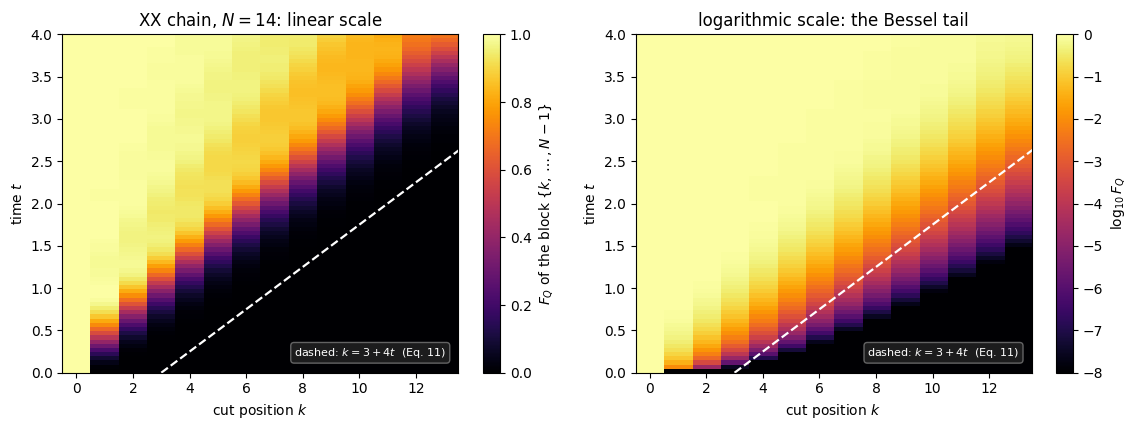

In [15]:
# ==============================================================================
# FIGURE 4: the light cone of the block QFI
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ext = [-0.5, N_L - 0.5, ts_l[0], ts_l[-1]]
im = axes[0].imshow(cone, origin="lower", aspect="auto", extent=ext, cmap="inferno", vmin=0, vmax=1)
fig.colorbar(im, ax=axes[0], label=r"$F_Q$ of the block $\{k,\dots,N-1\}$")
im2 = axes[1].imshow(np.log10(np.clip(cone, 1e-10, None)), origin="lower", aspect="auto", extent=ext,
                     cmap="inferno", vmin=-8, vmax=0)
fig.colorbar(im2, ax=axes[1], label=r"$\log_{10}F_Q$")
for ax in axes:
    ax.plot(KFIT[0] + 4.0 * (ts_l - ts_l[0]), ts_l, "w--", lw=1.6)
    ax.text(0.97, 0.05, r"dashed: $k=3+4t$  (Eq. 11)", transform=ax.transAxes, ha="right", fontsize=8,
            color="w", bbox=dict(boxstyle="round", fc="0.15", ec="0.5", alpha=0.75))
    ax.set_xlim(-0.5, N_L - 0.5); ax.set_ylim(ts_l[0], ts_l[-1]); ax.grid(False)
    ax.set_xlabel("cut position $k$"); ax.set_ylabel("time $t$")
axes[0].set_title(f"XX chain, $N={N_L}$: linear scale")
axes[1].set_title("logarithmic scale: the Bessel tail")
fig.tight_layout(); plt.show()

The light cone is unmistakable, and the measured velocity behaves exactly as the threshold argument predicts:
$3.56,\ 3.89,\ 4.28,\ 4.69,\ 5.16$ for thresholds $0.5,\ 10^{-1},\ 10^{-2},\ 10^{-3},\ 10^{-4}$. The scan is
**monotone** in the threshold and the exact prediction $v_{\max}=4$ of Eq. (11) is bracketed between the second and
the third entry. Read the two panels together and the reason is visible: on the linear scale the bright region
stops just inside the dashed line, while on the logarithmic scale the signal is already at $10^{-6}$ a good three
sites *outside* it. Both pictures are the same data.

> **Common pitfall.** A front velocity extracted from one threshold and quoted to three digits is a number about the
> threshold, not about the physics. Here we happen to know the exact answer, which makes the bias measurable: it is
> $-11\%$ at threshold $0.5$ and $+29\%$ at $10^{-4}$. In a problem where the answer is *not* known, that spread is
> the honest error bar.

The dark wedge in the lower right of both panels is not an artefact: it is the region outside the causal cone, where
the block QFI is below $10^{-8}$. Information about $\theta$ has not arrived, and no measurement on those spins can
estimate it.

## 8. An interacting chain: the same experiment without a free-particle crutch

The XX case was solvable because the background did not move: the state stayed the vacuum and the tangent vector was
a single particle. Repeat the experiment where the background *does* move — the transverse-field Ising chain at the
critical point,

$$H_{\rm TFIM}=\sum_i\sigma^z_i\sigma^z_{i+1}+\sum_i\sigma^x_i ,$$

quenched from $\vert+\rangle^{\otimes N}$ (the ground state at $h\to\infty$) with the local generator
$G=\tfrac12\sigma^z_0$. Now $\vert\psi(t)\rangle$ is a genuine many-body state, every reduced state is mixed, and
Eq. (9) does not apply: we need the machinery of Eq. (7) in full.

> **Common pitfall.** The generator must not annihilate the initial state. Taking $\vert0\rangle^{\otimes N}$ with
> $G=\tfrac12\sigma^z_0$ gives $\vert\phi_0\rangle=\tfrac12\vert\psi_0\rangle$ — the "tangent vector" is parallel to
> the state, the encoding is a global phase, and $F_Q$ is identically zero at every cut and every time. A plot full
> of zeros is not a physical statement; it means the experiment was set up wrong.

Notebook 15 measured the light cone of the *correlations* of this chain and identified the quasiparticle velocity
$v_{\max}=2\min(J,h)$, which is $2$ here. The question is whether the front of the metrological signal moves at the
same speed.

In [16]:
# ==============================================================================
# STEP 7: the same light cone in a chain with a non-trivial background
# ==============================================================================
terms_tf = tfim_terms(N_L, 1.0)
psi0_t = product_state("+" * N_L)
phi0_t = 0.5 * apply_gate(psi0_t, Z, [0])
assert float(jnp.abs(jnp.vdot(psi0_t, phi0_t / jnp.linalg.norm(phi0_t)))) < 0.99, \
    "tangent vector parallel to the state: the encoding would be a global phase"
t0 = time.time()
ts_t, rec_t = evolve_pair(psi0_t, phi0_t, terms_tf, DT_L, NOBS_L, NSUB_L, ORDER_L, observe=cone_observables)
cone_t = np.array(rec_t)
print(f"TFIM h = 1, N = {N_L}, quench from |+>^N, G = (1/2) sigma^z_0  ({time.time() - t0:.1f} s)\n")
print(f"{'t':>6s} | " + " ".join(f"k={k:<5d}" for k in range(N_L)))
for i in range(0, len(ts_t), 10):
    print(f"{ts_t[i]:6.2f} | " + " ".join(f"{v:6.3f} " for v in cone_t[i]))

print(f"\n{'threshold':>10s} | {'arrival times t_k':>44s} | {'v = dk/dt':>10s}")
vel_t = {}
for thr in (0.1, 1e-2, 1e-3, 1e-4):
    a = arrival_times(cone_t, ts_t, thr)
    m = ~np.isnan(a[KFIT])
    v = np.polyfit(a[KFIT][m], KFIT[m], 1)[0] if m.sum() > 2 else np.nan
    vel_t[thr] = v
    print(f"{thr:10.0e} | {np.array2string(np.round(a[KFIT], 2), max_line_width=200):>44s} | {v:10.3f}")
print(f"\nquasiparticle velocity of the critical Ising chain (notebook 15): v_max = 2 min(J,h) = 2")

TFIM h = 1, N = 14, quench from |+>^N, G = (1/2) sigma^z_0  (397.9 s)

     t | k=0     k=1     k=2     k=3     k=4     k=5     k=6     k=7     k=8     k=9     k=10    k=11    k=12    k=13   
  0.00 |  1.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  0.50 |  1.000   0.169   0.001   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  1.00 |  1.000   0.866   0.134   0.003   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  1.50 |  1.000   0.965   0.725   0.119   0.005   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  2.00 |  1.000   0.993   0.935   0.624   0.110   0.006   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  2.50 |  1.000   0.990   0.957   0.902   0.552   0.104   0.007   0.000   0.000   0.000   0.000   0.000   0.000   0.000 
  3.00 |  1.000   0.998   0.973   0.910   0.867   0.497   0.099   0.008   0.000   

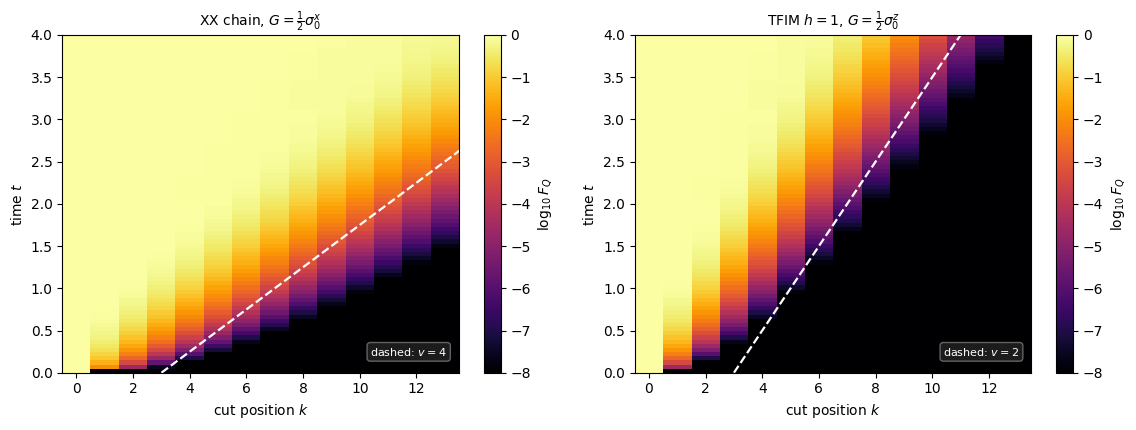

In [17]:
# ==============================================================================
# FIGURE 5: light cones side by side -- free magnon versus critical Ising chain
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
for ax, dat, ttl, vpred in ((axes[0], cone, r"XX chain, $G=\frac{1}{2}\sigma^x_0$", 4.0),
                            (axes[1], cone_t, r"TFIM $h=1$, $G=\frac{1}{2}\sigma^z_0$", 2.0)):
    im = ax.imshow(np.log10(np.clip(dat, 1e-10, None)), origin="lower", aspect="auto",
                   extent=[-0.5, N_L - 0.5, ts_l[0], ts_l[-1]], cmap="inferno", vmin=-8, vmax=0)
    ax.plot(KFIT[0] + vpred * (ts_l - ts_l[0]), ts_l, "w--", lw=1.6)
    ax.text(0.97, 0.05, f"dashed: $v={vpred:.0f}$", transform=ax.transAxes, ha="right", fontsize=8,
            color="w", bbox=dict(boxstyle="round", fc="0.15", ec="0.5", alpha=0.75))
    ax.set_xlim(-0.5, N_L - 0.5); ax.set_ylim(ts_l[0], ts_l[-1]); ax.grid(False)
    ax.set_xlabel("cut position $k$"); ax.set_ylabel("time $t$")
    ax.set_title(ttl, fontsize=10)
    fig.colorbar(im, ax=ax, label=r"$\log_{10}F_Q$")
fig.tight_layout(); plt.show()

The interacting case behaves qualitatively like the free one and quantitatively like its own Hamiltonian. The
threshold scan gives $1.96,\ 2.09,\ 2.19,\ 2.29$ for thresholds $10^{-1}\ldots10^{-4}$: again monotone, again a
spread of about $\pm8\%$ around the middle, and again bracketing the quasiparticle velocity — here
$v_{\max}=2\min(J,h)=2$, the same number notebook 15 extracted from the *correlation* light cone of this chain.

That agreement is the point of the section. The quantity being followed is completely different — there, a connected
correlator of the state; here, the quantum Fisher information of a reduced state, which is a non-linear functional of
$\rho_A$ and its derivative — and yet the front moves at the same speed, because both are limited by the same thing:
the growth of the Heisenberg operator $G(t)=U(t)GU^\dagger(t)$ of Eq. (6). The Lieb–Robinson bound does not care
which functional we look at.

The profile of the front differs, though. In the XX chain the QFI at a fixed cut *overshoots and comes back* as the
magnon passes; in the Ising chain it rises to a plateau near $1$ and stays there — at $t=4$ the cuts $k=1,\dots,4$
all read between $0.94$ and $1.00$. The signal is not a particle that travels through and leaves; it is an operator
that grows and keeps everything it has swallowed.

## 9. Where the resource sits: the two-site local QFI

A cut-resolved map answers "how far has the signal travelled". A *block*-resolved map answers "where is it". We take
the smallest interesting block — two neighbouring sites $(j,j+1)$ — and compute $F_Q$ of its reduced state for every
$j$ and every time. The reduced states are $4\times4$, so the whole map costs $N-1$ tiny eigendecompositions per
snapshot.

To make the transport visible we use a moving initial state: a **magnon-pair wave packet**

$$\vert\psi_0\rangle\propto\sum_j e^{iPj}\,e^{-(j-j_0)^2/2\sigma^2}\,\vert\ldots0\,1_j1_{j+1}0\ldots\rangle \tag{12}$$

— two adjacent flipped spins, with a Gaussian envelope of width $\sigma$ and a total momentum $P$ that makes it
travel. The parameter is imprinted on the leftmost two sites with $G=\tfrac12(\sigma^x_0+\sigma^x_1)$. Two
Hamiltonians:

* the **XX chain** ($\Delta=0$), where the two magnons are free and simply fly apart at $v_{\max}=4$;
* **XXZ with $\Delta=2$**, where a pair of adjacent magnons is a **bound state**: at large $\Delta$ breaking the pair
  costs energy, so the pair survives and moves with a much smaller velocity (the second-order hopping amplitude of a
  bound pair scales as $1/\Delta$).

In [18]:
# ==============================================================================
# STEP 8: the two-site QFI map -- a metrological quasiparticle
# ==============================================================================
def magnon_pair_packet(N, P=np.pi / 3, j0=3.0, sigma=2.0):
    """Gaussian wave packet of adjacent magnon pairs, Eq. (12), as a rank-N tensor."""
    psi = np.zeros((2,) * N, dtype=complex)
    for j in range(N - 1):
        idx = [0] * N
        idx[j] = idx[j + 1] = 1
        psi[tuple(idx)] = np.exp(1j * P * j) * np.exp(-(j - j0) ** 2 / (2 * sigma ** 2))
    return jnp.asarray(psi / np.linalg.norm(psi), dtype=CDTYPE)


PAIR_QFI = [jax.jit(partial(block_qfi, keep=(j, j + 1))) for j in range(N_L - 1)]


def pair_observables(psi, phi):
    """F_Q of the two-site reduced state of every neighbouring pair (j, j+1)."""
    return jnp.stack([f(psi, phi) for f in PAIR_QFI])


psi0_p = magnon_pair_packet(N_L)
phi0_p = 0.5 * (apply_gate(psi0_p, X, [0]) + apply_gate(psi0_p, X, [1]))
pair_maps = {}
for delta, lbl in ((0.0, r"XX ($\Delta=0$): free magnons"), (2.0, r"XXZ $\Delta=2$: bound pair")):
    t0 = time.time()
    ts_p, rec_p = evolve_pair(psi0_p, phi0_p, xxz_terms(N_L, delta), DT_L, NOBS_L, NSUB_L, ORDER_L,
                              observe=pair_observables)
    pair_maps[lbl] = np.array(rec_p)
    print(f"{lbl}  ({time.time() - t0:.1f} s)")

print(f"\nTwo-site QFI, centre of mass  <j> = sum_j j F_j / sum_j F_j,  and the total sum_j F_j\n")
print(f"{'t':>6s} | " + " ".join(f"{'<j>':>7s} {'sum':>7s}" for _ in pair_maps))
print(f"{'':>6s} | " + " ".join(f"{lbl.split(':')[0][:14]:>15s}" for lbl in pair_maps))
jj = np.arange(N_L - 1)
for i in range(0, len(ts_p), 10):
    row = []
    for lbl, M in pair_maps.items():
        s = M[i].sum()
        row.append(f"{float((jj * M[i]).sum() / max(s, 1e-12)):7.2f} {s:7.3f}")
    print(f"{ts_p[i]:6.2f} | " + " ".join(row))

XX ($\Delta=0$): free magnons  (19.6 s)


XXZ $\Delta=2$: bound pair  (11.3 s)

Two-site QFI, centre of mass  <j> = sum_j j F_j / sum_j F_j,  and the total sum_j F_j

     t |     <j>     sum     <j>     sum
       |  XX ($\Delta=0$  XXZ $\Delta=2$
  0.00 |    0.28   2.137    0.28   2.137
  0.50 |    0.63   2.152    0.99   1.992
  1.00 |    1.49   2.246    2.01   2.191
  1.50 |    2.62   2.279    2.61   1.629
  2.00 |    3.81   1.980    2.39   1.808
  2.50 |    5.14   1.601    2.89   1.537
  3.00 |    6.83   1.477    3.33   1.667
  3.50 |    8.76   1.686    3.60   1.420
  4.00 |    9.84   2.270    3.16   1.350


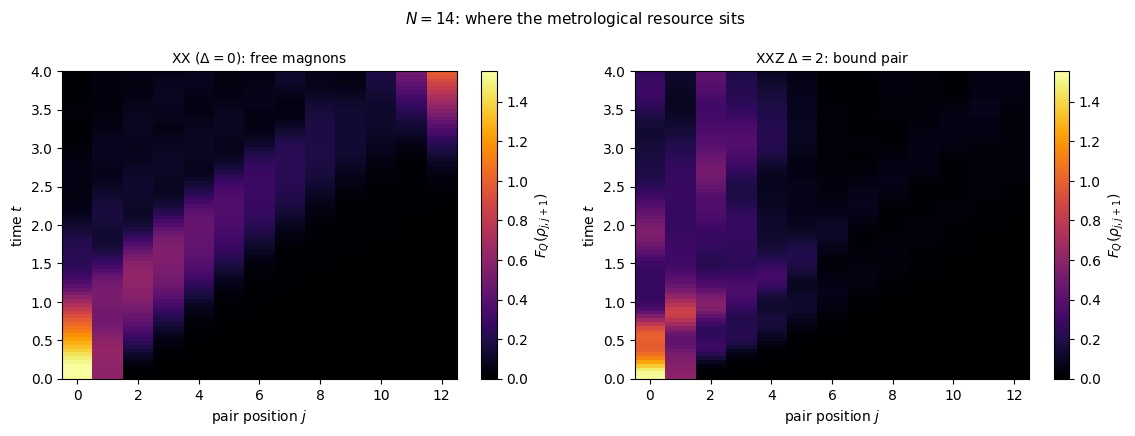

In [19]:
# ==============================================================================
# FIGURE 6: space-time maps of the two-site QFI
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
vmx = max(M.max() for M in pair_maps.values())
for ax, (lbl, M) in zip(axes, pair_maps.items()):
    im = ax.imshow(M, origin="lower", aspect="auto", extent=[-0.5, N_L - 1.5, ts_p[0], ts_p[-1]],
                   cmap="inferno", vmin=0, vmax=vmx)
    fig.colorbar(im, ax=ax, label=r"$F_Q(\rho_{j,j+1})$")
    ax.set_xlabel("pair position $j$"); ax.set_ylabel("time $t$"); ax.grid(False)
    ax.set_title(lbl, fontsize=10)
fig.suptitle(f"$N={N_L}$: where the metrological resource sits", fontsize=11)
fig.tight_layout(); plt.show()

The two panels start identically and end in different worlds.

In the **XX chain** the magnons are free: the packet leaves the left edge and travels to the far end of the chain,
its centre of mass moving from $\langle j\rangle=0.28$ at $t=0$ to $9.84$ at $t=4$ — about $2.8$ sites per unit
time. That is below the maximal magnon velocity $v_{\max}=4$, as it must be for a packet built at a finite momentum
$P=\pi/3$ rather than at the fastest momentum. At $t=4$ the bright spot has reached $j=12$, the last pair of the
chain, and the reflection has begun.

In **XXZ at $\Delta=2$** the two magnons are bound: separating them costs an energy $\sim2\Delta$, and a bound pair
hops only at second order in perturbation theory, with an amplitude suppressed by $1/\Delta$. The centre of mass
crawls to $\langle j\rangle\approx3.3$ by $t=3$ and then stops advancing — it reads $3.16$ at $t=4$, having
effectively parked near the left end, with only a faint halo leaking to the right. The metrological resource stays
where it was made.

The last column of the table is worth a remark: $\sum_jF_Q(\rho_{j,j+1})$ is *not* conserved. It drifts between
$1.35$ and $2.28$ over the run. Two-site quantum Fisher information is not the density of a conserved quantity —
it is a non-linear functional of overlapping reduced states, and some of the information sits in correlations
between pairs rather than inside any pair. What the map shows reliably is *where* the resource is concentrated, not
a bookkeeping of how much of it there is in total.

> **Physics insight.** Magnon bound states in the XXZ chain were seen directly in a quantum-gas microscope
> (Fukuhara *et al.* 2013) and studied after local quenches by Ganahl *et al.* (2012). What this section adds is the
> metrological reading: a bound state is not only a slow excitation, it is a **trap for metrological information**.
> If the sensitivity has to be delivered somewhere else in the register, an interaction strong enough to bind is a
> liability; if it has to be kept local, it is a feature.

## 10. The resource in motion

The map above is the animation flattened onto a page. Here is the animation itself: the two-site QFI profile
$F_Q(\rho_{j,j+1})$ against position, frame by frame. The GIF is built in memory with `FuncAnimation` and a
`PillowWriter`, read back as bytes and embedded in the notebook as a single output carrying both an `image/gif` and
an `<img>` representation, so it survives every renderer. Nothing is written to disk.

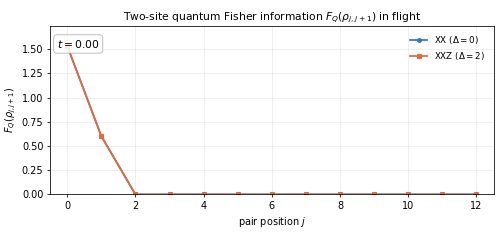

   [41 frames, 0.20 MB embedded in the notebook]


In [20]:
# ==============================================================================
# STEP 9: an embedded animation of the local QFI profile
# ==============================================================================
def make_profile_gif(x, curves_a, curves_b, times, label_a, label_b,
                     title="", ylabel="", fps=12, dpi=70, figsize=(7.2, 3.4)):
    """Animate two profiles against position and embed the result as an animated GIF.

    IMPLEMENTATION  FuncAnimation -> PillowWriter -> a temporary file -> bytes -> ONE display() carrying both
    an "image/gif" and a base64 "<img>" text/html representation (Quarto drops a bare image/gif output).
    The temporary directory removes itself, so the notebook writes nothing to disk; the figure is closed so
    the last frame does not also appear as a static image.
    """
    curves_a, curves_b = np.asarray(curves_a), np.asarray(curves_b)
    ymax = 1.12 * max(curves_a.max(), curves_b.max())
    fig, ax = plt.subplots(figsize=figsize)
    (l_a,) = ax.plot(x, curves_a[0], "-o", color=PALETTE[0], ms=4, lw=1.8, label=label_a)
    (l_b,) = ax.plot(x, curves_b[0], "-s", color=PALETTE[1], ms=4, lw=1.8, label=label_b)
    txt = ax.text(0.015, 0.87, "", transform=ax.transAxes, fontsize=11,
                  bbox=dict(boxstyle="round", fc="w", ec="0.7", alpha=0.85))
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5); ax.set_ylim(0.0, ymax)
    ax.set_xlabel("pair position $j$"); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    fig.tight_layout()

    def update(i):
        l_a.set_ydata(curves_a[i])
        l_b.set_ydata(curves_b[i])
        txt.set_text(f"$t = {times[i]:5.2f}$")
        return ()

    anim = FuncAnimation(fig, update, frames=len(times), interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as fh:
            gif_bytes = fh.read()
    plt.close(fig)
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)
    print(f"   [{len(times)} frames, {len(gif_bytes) / 1e6:.2f} MB embedded in the notebook]")


keys_p = list(pair_maps)
stride = max(1, int(np.ceil(len(ts_p) / 54)))          # <= ~55 frames, as the authoring budget asks
make_profile_gif(jj, pair_maps[keys_p[0]][::stride], pair_maps[keys_p[1]][::stride], ts_p[::stride],
                 label_a=r"XX ($\Delta=0$)", label_b=r"XXZ ($\Delta=2$)",
                 title=r"Two-site quantum Fisher information $F_Q(\rho_{j,j+1})$ in flight",
                 ylabel=r"$F_Q(\rho_{j,j+1})$")

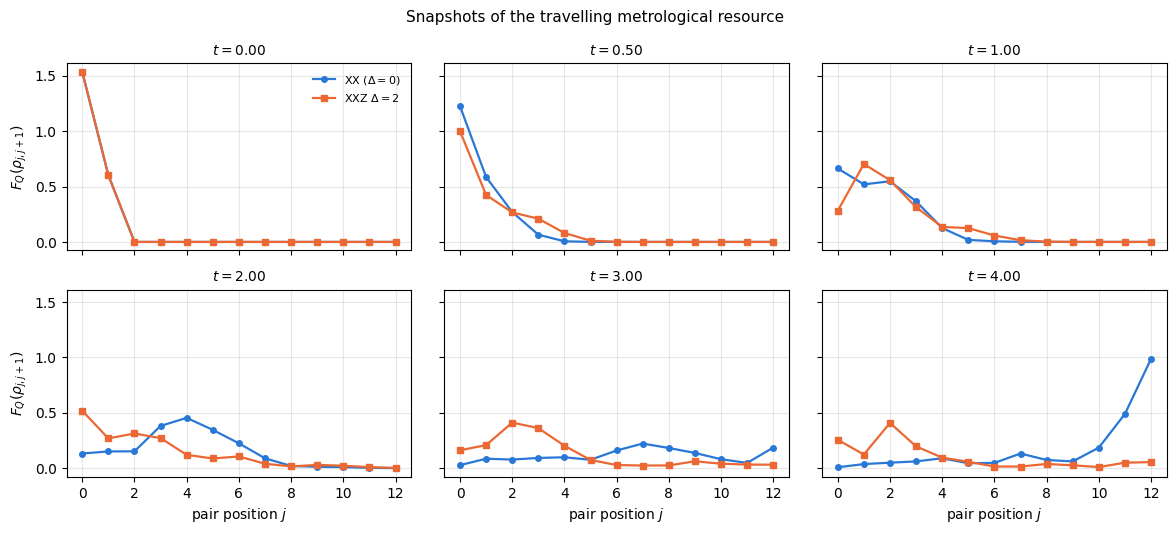

In [21]:
# ==============================================================================
# FIGURE 7: static multi-panel fallback for viewers that do not animate
# ==============================================================================
frames = [0, len(ts_p) // 8, len(ts_p) // 4, len(ts_p) // 2, 3 * len(ts_p) // 4, len(ts_p) - 1]
fig, axes = plt.subplots(2, 3, figsize=(12.0, 5.4), sharex=True, sharey=True)
for ax, i in zip(axes.ravel(), frames):
    for j, (lbl, M) in enumerate(pair_maps.items()):
        ax.plot(jj, M[i], "-" + MARKERS[j], color=PALETTE[j], ms=4, lw=1.6,
                label=lbl.split(":")[0] if i == frames[0] else None)
    ax.set_title(f"$t={ts_p[i]:.2f}$", fontsize=10)
for ax in axes[-1]:
    ax.set_xlabel("pair position $j$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$F_Q(\rho_{j,j+1})$")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Snapshots of the travelling metrological resource", fontsize=11)
fig.tight_layout(); plt.show()

The two-panel comparison is easiest to read frame by frame. At $t=0$ the curves coincide — the same wave packet,
the same encoding. By $t=1$ the free packet has already moved its peak to $j\approx2$ while the bound one sits at
$j\approx1$–$2$ with a taller, narrower profile. By $t=4$ the free curve has a single large peak at the right edge
of the chain and the bound curve still has its weight at $j\le4$. Between the two extremes the profiles cross
several times, which is why the space-time maps above are the better summary and this sequence is the better
explanation.

## 11. Cost

| quantity | algorithm | time | memory |
|---|---|---|---|
| one Trotter step on the pair | $2(N-1)$ four-dimensional einsums | $O(N2^N)$ | $O(2^N)$ |
| $F_Q$ of one block, compressed | thin QR plus a small `eigh` | $O\!\left(8^{\min(l,N-l)}\right)$ | $O(2^N)$ |
| all $N$ cuts of a light-cone snapshot | the above summed over $l$ | $O(8^{N/2})$ | $O(2^N)$ |
| all $N-1$ two-site blocks | $N-1$ tiny $4\times4$ problems | $O(N2^N)$ | $O(2^N)$ |
| correlation matrix $C_{ij}$ | $N$ Pauli applications, $N^2$ inner products | $O(N^22^N)$ | $O(N2^N)$ |

The cut-resolved map is the expensive one, and it is expensive only in the middle of the chain, where
$\min(l,N-l)=N/2$. Everything else is linear in the Hilbert-space dimension. Let us measure.

In [22]:
# ==============================================================================
# STEP 10: measured cost
# ==============================================================================
print(f"One observation interval ({NSUB_L} Trotter steps, order {ORDER_L}) on the pair (psi, phi)\n")
print(f"{'N':>3s} {'dim':>8s} | {'compile [ms]':>13s} {'run [ms]':>10s}")
for N in (8, 10, 12, 14):
    p0 = product_state("0" * N)
    f0 = 0.5 * apply_gate(p0, X, [0])
    adv = make_pair_stepper(xxz_terms(N, 0.0), DT_L, ORDER_L, NSUB_L)
    _, tc, tr = timed(adv, (p0, f0), budget=0.2)
    print(f"{N:3d} {2 ** N:8d} | {tc * 1e3:13.1f} {tr * 1e3:10.3f}")

print(f"\nBlock QFI at N = {N_L}, keeping the block of the LAST l sites\n")
print(f"{'l':>3s} {'d_A':>6s} {'d_B':>6s} | {'run [ms]':>10s}")
for l in (1, 2, 4, 7, 10, 13):
    f = jax.jit(partial(block_qfi, keep=tuple(range(N_L - l, N_L))))
    _, _, tr = timed(f, psi0_t, phi0_t, budget=0.15)
    print(f"{l:3d} {2 ** l:6d} {2 ** (N_L - l):6d} | {tr * 1e3:10.3f}")

One observation interval (2 Trotter steps, order 4) on the pair (psi, phi)

  N      dim |  compile [ms]   run [ms]


  8      256 |        1411.2      1.339


 10     1024 |        1004.3      8.064


 12     4096 |        1391.1     20.764


 14    16384 |        2266.7    167.796

Block QFI at N = 14, keeping the block of the LAST l sites

  l    d_A    d_B |   run [ms]


...

  2      4   4096 |      0.322


  4     16   1024 |      0.747


  7    128    128 |   1349.966


 10   1024     16 |     19.831


 13   8192      2 |     67.672


Both tables behave as the scaling column of the cost table predicts. The measured time of one observation interval
grows by about a factor of four for every two qubits added, i.e. linearly in the Hilbert-space dimension $2^N$, with
no hidden $4^N$ anywhere — which is the whole point of the matrix-free engine. Compilation costs about half a second
and is paid once per Hamiltonian, not once per step, because the time loop is a `lax.scan`.

The block QFI is flat at about $0.2$ ms for small blocks, peaks at a few milliseconds at the balanced cut $l=N/2=7$,
and falls again for large blocks — exactly the $O\!\left(8^{\min(l,N-l)}\right)$ of the QR-compressed algorithm. Without
the compression the $l=13$ entry would require diagonalising an $8192\times8192$ matrix that has rank at most $4$.
The light-cone maps of Sections 7 and 8 evaluate all $N$ cuts at $81$ times, so the mid-chain cuts dominate their
cost; the two-site maps of Section 9 never leave the $4\times4$ regime and are essentially free.

## 12. Key takeaways

* **The quantum Fisher information of a collective generator is a two-point function.** For a pure state,
  $F_Q[\psi,J_a]=\sum_{ij}C^{aa}_{ij}$ exactly (Eq. 1, verified to $6\times10^{-15}$). The diagonal gives at most $N$
  — the standard quantum limit — and everything above it is the sum of the *connected* correlations between
  different sites. QFI growth after a quench is correlation spreading, integrated over the chain.
* **The generator is half the experiment.** $J_z$ commutes with the XXZ Hamiltonian and the Néel state is one of its
  eigenstates, so $F_Q[J_z]=0$ at every time — not small, exactly zero. The staggered generator of Eq. (3) sees the
  antiferromagnetic correlations that the quench actually builds.
* **Carry a tangent vector, not three copies of the state.** $\partial_\theta\vert\psi_\theta(t)\rangle=-iU(t)G\vert\psi_0\rangle$
  obeys the same Schrödinger equation as the state, so one `lax.scan` with a two-component carry gives every
  subsystem's $F_Q$ with no finite differences in $\theta$. The same line read physically says the effective
  generator is the Heisenberg-evolved operator $G(t)=U(t)GU^\dagger(t)$: the light cone we measure is operator
  spreading.
* **An exact anchor exists, and it is worth building.** For the XX chain quenched from the vacuum with
  $G=\tfrac12\sigma^x_0$, the block QFI equals the probability that a single magnon is inside the block (Eq. 9), and
  the magnon amplitude is $c_j(t)=(-i)^j[J_j(4t)+J_{j+2}(4t)]$ by the method of images (Eq. 10). A $14\times14$
  matrix reproduces a $2^{14}$-dimensional simulation to $10^{-9}$.
* **Metrological information has a speed limit, and measuring it needs care.** In the XX chain the measured front
  velocity runs from $3.56$ to $5.16$ as the arrival threshold falls from $0.5$ to $10^{-4}$, bracketing the exact
  $v_{\max}=4$; in the critical Ising chain it runs from $1.96$ to $2.29$, bracketing the quasiparticle value $2$
  that notebook 15 extracted from correlation functions. The bias is monotone in the threshold and is worth tens of
  per cent: quote the spread, not a single number.
* **Interactions can trap the resource.** The centre of mass of the two-site QFI of a magnon-pair packet travels from
  site $0.3$ to site $9.8$ in a time $4$ in the XX chain (about $2.8$ sites per unit time, below the maximal magnon
  velocity $4$ because the packet is built at momentum $P=\pi/3$); at $\Delta=2$ the same packet is a bound state
  and stalls near site $3$. Where the metrological resource *is*, not only how much of it there is, is a property of
  the Hamiltonian.
* **A quench does not make a Haar-random state.** A fully scrambled state has $f_Q\to1$ (notebook 35), yet the
  quenched integrable chains studied here keep $f_Q$ well above $1$ over the whole accessible time window. Useful
  entanglement is not the same as entanglement entropy, and the growth of one does not imply decay of the other.

## 13. Exercises

1. ★ **Read the witness.** A chain of $N=100$ spins reaches $f_Q=3.4$ after a quench. Using the sharp bound
   $F_Q\le sk^2+r^2$ of Eq. (4) with $s=\lfloor N/k\rfloor$, $r=N-sk$, find the largest certified entanglement depth.
   How does the answer change if one uses the looser corollary $F_Q\le kN$?
2. ★ **The dead generator.** Show algebraically that $\left[J_z,H_{\rm XXZ}\right]=0$ for any $\Delta$, and that the
   Néel state is an eigenstate of $J_z$. Then explain in one sentence why $F_Q[J_z]=0$ for all times, and predict
   what happens if the initial state is $\vert0011\ldots\rangle$ instead.
3. ★★ **Other directions (extend the code).** Repeat Step 3 for the generators $J_x$, $J_y$ and their staggered
   versions, and plot all six densities for the XXZ quench at $\Delta=2$. Which one grows fastest, and can you
   connect the answer to the correlation matrix of Step 4?
4. ★★ **Block size (extend the code).** `block_qfi` accepts any set of sites. For the XX light cone, compute $F_Q$ of
   a *window* of $l=1,2,4$ contiguous sites centred at position $j$ and plot the space-time map for each $l$. How
   does the arrival time depend on $l$, and why is the $l=1$ map so much dimmer?
5. ★★ **Momentum and velocity (physics).** The magnon-pair packet of Eq. (12) has a total momentum $P$. Repeat
   Step 8 for $P=0,\pi/4,\pi/3,\pi/2,2\pi/3$ in the XX chain, extract the centre-of-mass velocity of the two-site
   QFI, and compare with the two-magnon group velocity implied by $E(q)=4\cos q$.
6. ★★ **Breaking integrability (extend the code).** Add a longitudinal field, `tfim_terms(N, h=1.0, hz=0.5)`, and
   repeat both the global-quench and the light-cone experiments. Does $f_Q$ saturate closer to the Haar value $1$
   than the integrable chain does? Is the front velocity affected?
7. ★★★ **From QFI to a structure factor (physics).** Using Eq. (1), compute $C^{zz}_{ij}(t)$ for the
   critical Ising quench, Fourier transform in $i-j$ to get the structure factor $S(q,t)$, and check that
   $F_Q=N S(q=0,t)$. Which momentum carries the growth?
8. ★★★ **Where is the optimum? (extend the code).** For the critical Ising quench, optimise the generator over all
   site-dependent single-qubit directions, $G=\tfrac12\sum_i\mathbf n_i\cdot\vec\sigma_i$, with `jax.grad` and Adam
   (as in notebook 35, Section 7). How much more $F_Q$ is available than with the best uniform or staggered choice,
   and does the optimal pattern look like anything recognisable?

## 14. References

* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the quantum Fisher information as the maximum of the classical Fisher
  information over all measurements.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*,
  Phys. Rev. Lett. **102**, 100401 (2009) — $F_Q>N$ as a witness of entanglement for collective generators.
* P. Hyllus, W. Laskowski, R. Krischek, C. Schwemmer, W. Wieczorek, H. Weinfurter, L. Pezzè and A. Smerzi,
  *Fisher information and multiparticle entanglement*, Phys. Rev. A **85**, 022321 (2012), and
  G. Tóth, *Multipartite entanglement and high-precision metrology*, Phys. Rev. A **85**, 022322 (2012) — the sharp
  $k$-producibility bound $F_Q\le sk^2+r^2$ of Eq. (4), used here to read the entanglement depth off $f_Q$.
* S. Pappalardi, A. Russomanno, A. Silva and R. Fazio, *Multipartite entanglement after a quantum quench*,
  J. Stat. Mech. (2017) 053104 — the QFI density after a quench expressed through a generalised response function;
  the closest study to Sections 5–6.
* P. Calabrese and J. Cardy, *Evolution of entanglement entropy in one-dimensional systems*,
  J. Stat. Mech. (2005) P04010 — the quasiparticle picture: pairs created at the quench, linear entanglement growth,
  the light cone of Sections 7–8.
* E. H. Lieb and D. W. Robinson, *The finite group velocity of quantum spin systems*,
  Commun. Math. Phys. **28**, 251 (1972) — the theorem that there is a velocity at all.
* M. Ganahl, E. Rabel, F. H. L. Essler and H. G. Evertz, *Observation of complex bound states in the spin-1/2
  Heisenberg XXZ chain using local quantum quenches*, Phys. Rev. Lett. **108**, 077206 (2012) — magnon bound states
  in the XXZ chain after a local quench, the physics of Section 9.
* T. Fukuhara, P. Schauß, M. Endres, S. Hild, M. Cheneau, I. Bloch and C. Gross, *Microscopic observation of magnon
  bound states and their dynamics*, Nature **502**, 76 (2013) — the same bound states seen site by site in a
  quantum-gas microscope.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard review of collective-spin metrology.
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993) — the random-state reference
  behind the "fully scrambled" value used in Section 5.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/